<a href="https://colab.research.google.com/github/Chaitu1212/flood-prediction-ML-model/blob/main/flood_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from IPython.display import display, HTML

Load Dataset

In [43]:
data = pd.read_excel("flood dataset.xlsx")

data.head()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
0,29,70,30,3248.6,73.4,386.2,2122.8,666.1,274.866667,649.9,0
1,28,75,40,3326.6,9.3,275.7,2403.4,638.2,130.300000,256.4,1
2,28,75,42,3271.2,21.7,336.3,2343.0,570.1,186.200000,308.9,0
3,29,71,44,3129.7,26.7,339.4,2398.2,365.3,366.066667,862.5,0
4,31,74,40,2741.6,23.4,378.5,1881.5,458.1,283.400000,586.9,0


checking the first five rows of the dataset

In [44]:
print(data.head())

   Temp  Humidity  Cloud Cover  ANNUAL  Jan-Feb  Mar-May  Jun-Sep  Oct-Dec  \
0    29        70           30  3248.6     73.4    386.2   2122.8    666.1   
1    28        75           40  3326.6      9.3    275.7   2403.4    638.2   
2    28        75           42  3271.2     21.7    336.3   2343.0    570.1   
3    29        71           44  3129.7     26.7    339.4   2398.2    365.3   
4    31        74           40  2741.6     23.4    378.5   1881.5    458.1   

      avgjune    sub  flood  
0  274.866667  649.9      0  
1  130.300000  256.4      1  
2  186.200000  308.9      0  
3  366.066667  862.5      0  
4  283.400000  586.9      0  


Checking for Missing Values

In [45]:
print(data.isnull().sum())

Temp           0
Humidity       0
Cloud Cover    0
ANNUAL         0
Jan-Feb        0
Mar-May        0
Jun-Sep        0
Oct-Dec        0
avgjune        0
sub            0
flood          0
dtype: int64


In [46]:
data = data.fillna(data.mean())

Correlation Matrix

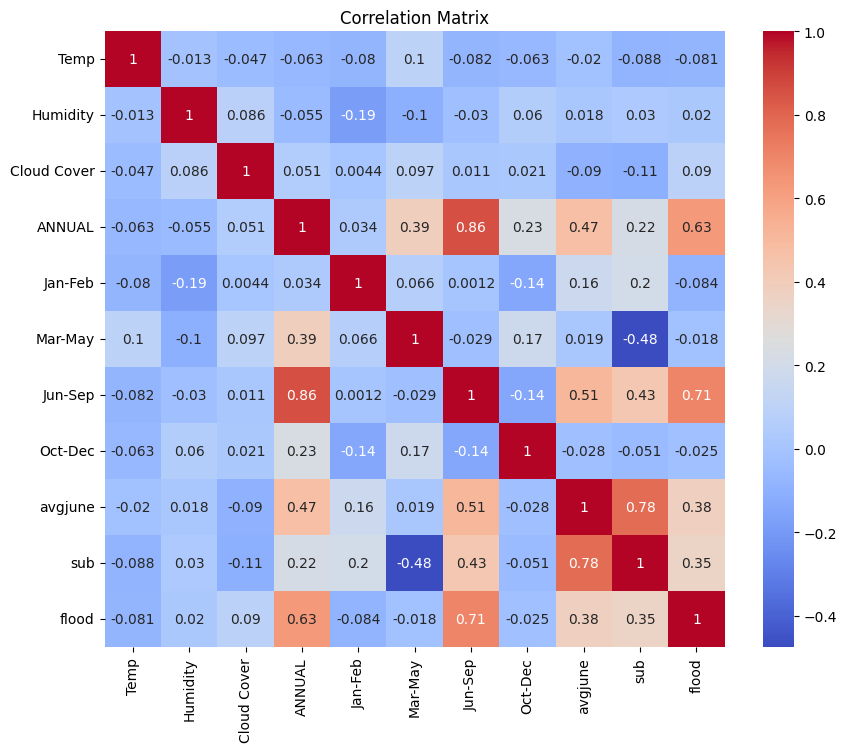

In [47]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Train-test split

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Feature Scaling

In [49]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Train Model

In [50]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

Prediction on Test set

In [51]:
y_pred = model.predict(X_test)

Model Evaluation Metrics

In [52]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


Classification Report

In [53]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         3

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



Confusion Matrix

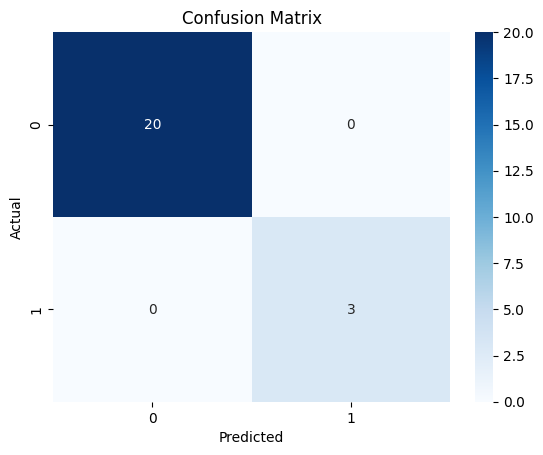

In [54]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Predictions

In [63]:
def format_values(values):
    features = ['Temp', 'Humidity', 'Cloud Cover', 'ANNUAL', 'Jan-Feb',
                'Mar-May', 'Jun-Sep', 'Oct-Dec', 'avgjune', 'sub']
    return "<br>".join([f"{f}: {v}" for f, v in zip(features, values)])

# Display High Flood Risk box
display(HTML(f"""
<h1 style='color:white; background-color:red; padding:20px; text-align:center; border-radius:10px;'>
⚠️ HIGH FLOOD RISK
</h1>
<div style='background-color:#ffe5e5; padding:15px; border-radius:10px; color:#333333; font-weight:600;'>
<b>Input Values:</b><br>
{format_values(high_values)}
</div>
"""))

# Display Low Flood Risk box
display(HTML(f"""
<h1 style='color:white; background-color:green; padding:20px; text-align:center; border-radius:10px;'>
✅ LOW FLOOD RISK
</h1>
<div style='background-color:#e6ffe6; padding:15px; border-radius:10px; color:#333333; font-weight:600;'>
<b>Input Values:</b><br>
{format_values(low_values)}
</div>
"""))